In [195]:
from datasets import load_dataset
import pandas as pd
import numpy as np
from astropy.timeseries import LombScargle
from scipy.stats import skew, kurtosis
from tqdm import tqdm
import matplotlib.pyplot as plt

print("Loading TESS dataset...")
tess_data = load_dataset(
    "MultimodalUniverse/tess",
    split="train",
    streaming=True
)
print("Loaded")

Loading TESS dataset...
Loaded


In [256]:
#parameter functions
def compute_features(time, flux, flux_err, min_period=0.1, max_period=15.0):
              
    min_freq = 1 / max_period
    max_freq = 1 / min_period
    
    ls = LombScargle(time, flux, flux_err)
    frequency, power = ls.autopower(
        minimum_frequency=min_freq,
        maximum_frequency=max_freq,
        samples_per_peak=10  # More samples for better resolution
    )
    
    best_freq = frequency[np.argmax(power)]
    best_period = 1 / best_freq
    best_power = np.max(power)
    
    return {
        'period': best_period,
        'ls_power': best_power,
        'amplitude': np.ptp(flux),
        'mean_flux': np.mean(flux),
        'flux_err': np.std(flux),
        'n_points': len(time),
    }

def clean_para(time, flux, flux_err):
    time, flux, flux_err = np.array(time), np.array(flux), np.array(flux_err)
    mask = ~(np.isnan(time) | np.isnan(flux)) & (flux > 0)  
    time, flux, flux_err = time[mask], flux[mask], flux_err[mask]
    
    if len(time) == 0:
        return time, flux, flux_err  
    
    med = np.median(flux)
    flux_norm = flux / med - 1.0
    flux_err_norm = flux_err / med
    return time, flux_norm, flux_err_norm


def rem_outliers(time, flux, flux_err=None, sigma=5):

    if flux_err is None:
        flux_err = np.ones_like(flux) * np.std(flux) * 0.01

    med = np.nanmedian(flux)
    mad = np.nanmedian(np.abs(flux - med))

    if mad == 0 or np.isnan(mad):
        mad = np.nanstd(flux)

    mask = np.abs(flux - med) < sigma * 1.4826 * mad

    return time[mask], flux[mask], flux_err[mask]

#Plot functions
def light_curve_output(star_dat):
    object_id = star_dat['object_id']
    print(f"object id for light curve: {object_id}")
    
    time = star_dat['time']
    flux = star_dat['flux']

    '''
    idx = np.linspace(0, len(time)-1, max_points, dtype=int)
    time, flux = time[idx], flux[idx]
    '''

    plt.figure(figsize=(10, 4))
    plt.plot(time, flux, '.', markersize=2, alpha=0.7)
    plt.title(f"Light Curve: {star_dat['object_id']}")
    plt.xlabel("Time [days]")
    plt.ylabel("Flux")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def phase_fold(time, period, t0=None):
    """
    Fold a light curve on a given period and sort it for plotting.
    """
    if t0 is None:
        t0 = np.nanmin(time)
    phase = ((time - t0) / period) % 1.0
    
    return phase



In [258]:
results = []
max_samples = 20

for i, sample in enumerate(tqdm(tess_data, total=max_samples)):
    if i >= max_samples:
        break

    lc = sample['lightcurve']
    time = np.array(lc['time'])
    flux = np.array(lc['flux'])
    flux_err = np.array(lc.get('flux_err', np.ones_like(flux) * 0.01))

    time, flux, flux_err = clean_para(time, flux, flux_err)

    time, flux, flux_err = rem_outliers(time, flux, flux_err)


    # Compute features
    features = compute_features(time, flux, flux_err)

    period = features['period']
    #phase, flux_sorted = phase_fold(time, period)

    phase = phase_fold(time, period)
    

    # Store result dictionary
    result = {
        'object_id': sample['object_id'],
        'ra': sample['RA'],
        'dec': sample['DEC'],
        'time': time,
        'flux': flux,
        'phase': phase,
        **features
    }
    results.append(result)

# Convert to DataFrame if desired
df = pd.DataFrame(results)
print(df.head())

100%|█████████████████████████████████████████████| 20/20 [00:04<00:00,  4.19it/s]

   object_id          ra        dec  \
0  229761376  281.337097  65.921844   
1  229761447  281.373016  66.071999   
2  229761513  281.238312  66.216614   
3  229766703  281.512543  66.015427   
4  229766711  281.514160  66.002975   

                                                time  \
0  [2883.172607421875, 2883.175048828125, 2883.17...   
1  [2883.172607421875, 2883.175048828125, 2883.17...   
2  [2883.172607421875, 2883.175048828125, 2883.17...   
3  [2883.200439453125, 2883.205078125, 2883.20751...   
4  [2883.172607421875, 2883.175048828125, 2883.17...   

                                                flux  \
0  [0.00016417471541774198, 0.0006967712052023955...   
1  [-0.0007702337631472211, -0.001056335134521080...   
2  [0.0003483446908745247, 0.00024458918524095097...   
3  [0.003351633354539141, 0.0037066360432156387, ...   
4  [-0.00344709549042832, -0.004007325628782588, ...   

                                               phase     period  ls_power  \
0  [0.0, 0.000

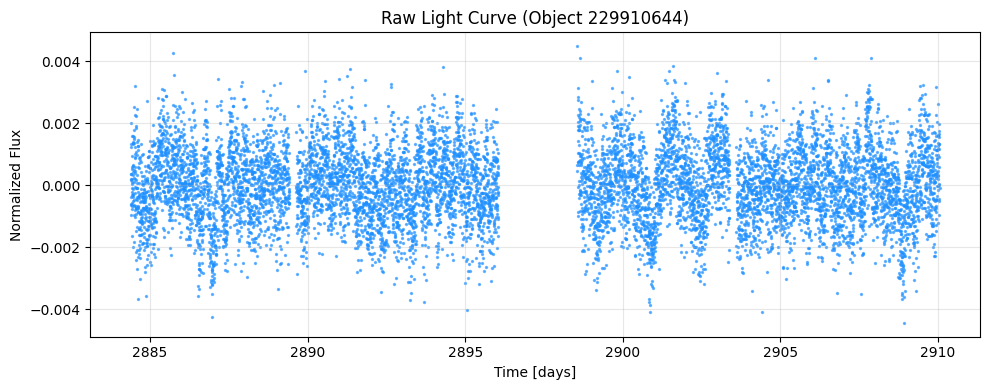

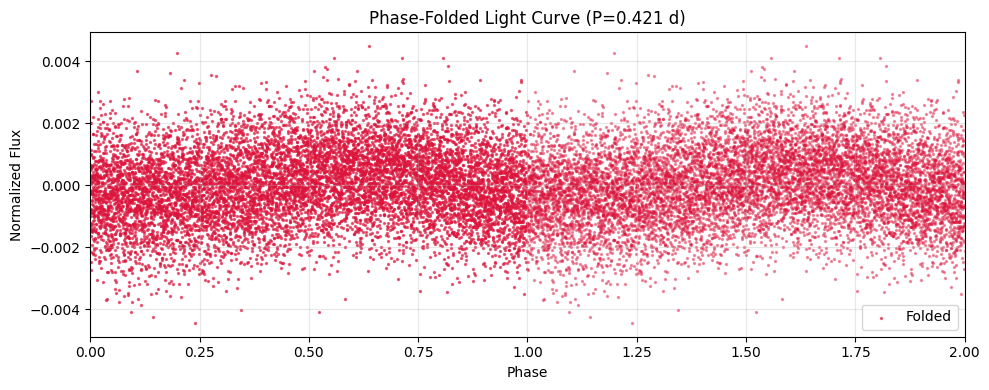

In [268]:
star = results[17]

# Plot 1: Raw light curve
plt.figure(figsize=(10, 4))
plt.scatter(star['time'], star['flux'], s=2, alpha=0.6, color='dodgerblue')
plt.xlabel('Time [days]')
plt.ylabel('Normalized Flux')
plt.title(f"Raw Light Curve (Object {star['object_id']})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))

# Sort by phase for plotting
sort_idx = np.argsort(star['phase'])
phase_sorted = star['phase'][sort_idx]
flux_sorted = star['flux'][sort_idx]

# Plot primary cycle
plt.scatter(phase_sorted, flux_sorted, s=2, alpha=0.6, color='crimson', label='Folded')
# Plot repeated cycle for continuity
plt.scatter(phase_sorted + 1, flux_sorted, s=2, alpha=0.4, color='crimson')

plt.xlabel('Phase')
plt.ylabel('Normalized Flux')
plt.title(f"Phase-Folded Light Curve (P={star['period']:.3f} d)")
plt.xlim(0, 2)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



In [248]:
var_stars = []
for star in results:
    if (star['ls_power'] > 0.2 and          # Moderate periodogram peak
                star['fap'] < 0.05 and               # Reasonably significant
                star['signal_to_noise'] > 2 and      # Some signal above noise
                star['amplitude'] > 0.0005):  
        var_stars.append(star)
print(len(var_stars))

0


In [246]:
star = results[6]

print("="*70)
print(f"STAR DATA: {star['object_id']}")
print("="*70)
print(f"Object ID:        {star['object_id']}")
print(f"RA, Dec:          {star['ra']:.6f}, {star['dec']:.6f}")
print(f"Period:           {star['period']:.6f} days")
print(f"LS Power:         {star['ls_power']:.4f}")
#print(f"False Alarm Prob: {star['fap']:.2e}")
print(f"Amplitude:        {star['amplitude']:.6f}")
#print(f"Signal-to-Noise:  {star['signal_to_noise']:.2f}")
print(f"N Points:         {star['n_points']}")
print("="*70)

STAR DATA: 229766854
Object ID:        229766854
RA, Dec:          281.998779, 66.115906
Period:           0.968348 days
LS Power:         0.0083
Amplitude:        0.013570
N Points:         10563


Loading TESS dataset...
Loaded

Processing light curves to find variable stars...
(Most stars are NOT variable - we need to check many to find good ones)


100%|█████████████████████████████████████████████| 20/20 [00:04<00:00,  4.28it/s]



PROCESSED 20 OBJECTS

Top 10 by Lomb-Scargle Power:
object_id    period  ls_power           fap  amplitude  signal_to_noise
229910234  1.892878  0.729958  0.000000e+00   0.021004         8.611643
229910746  2.499117  0.435354  0.000000e+00   0.048629         7.415138
229766711  0.144573  0.131350  0.000000e+00   0.010363         8.290036
229910721  1.752719  0.062962 1.508257e-132   0.018855         7.851621
229766703  3.278118  0.060580 1.076815e-140   0.007856         8.850815
229910644  0.421225  0.056179 4.876334e-118   0.008938         7.464100
229761447  9.293948  0.040057  1.310150e-90   0.008237         8.050473
229766793  0.872794  0.017119  1.240055e-35   0.006497         8.236088
229761513 10.369775  0.012454  1.223971e-24   0.004504         7.516675
229910017  0.108500  0.011772  4.961553e-23   0.005138         9.558991


QUALITY-BASED FILTERING RESULTS
Total objects processed:        20
High-quality variables:         2 (LS power > 0.3)
Medium-quality variables:       2 (

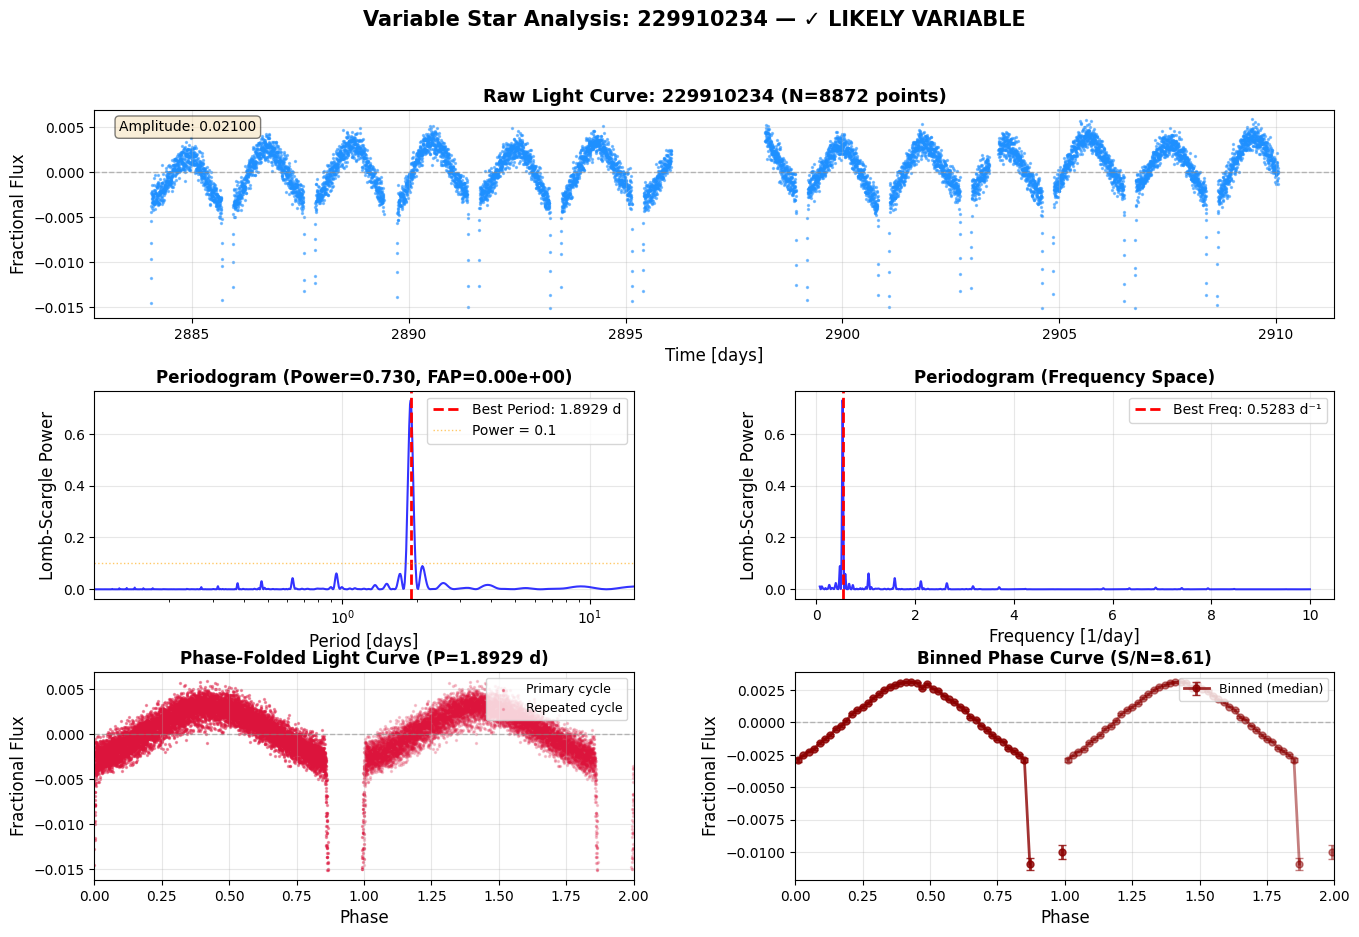


ANALYSIS SUMMARY: 229910234
  Period:              1.892878 days
  LS Power:            0.7300  (Strong)
  False Alarm Prob:    0.00e+00  (Significant)
  Amplitude:           0.021004
  Signal-to-Noise:     8.61
  N Points:            8872
  RA, Dec:             287.4042, 61.0644

INTERPRETATION GUIDE:
  • LS Power > 0.3:     Strong periodic signal
  • LS Power 0.1-0.3:   Marginal signal, may be variable
  • LS Power < 0.1:     Likely just noise/non-periodic
  • FAP < 0.01:         Statistically significant period
  • FAP > 0.01:         Period may be spurious


HIGH-QUALITY VARIABLE #2 (results[19])


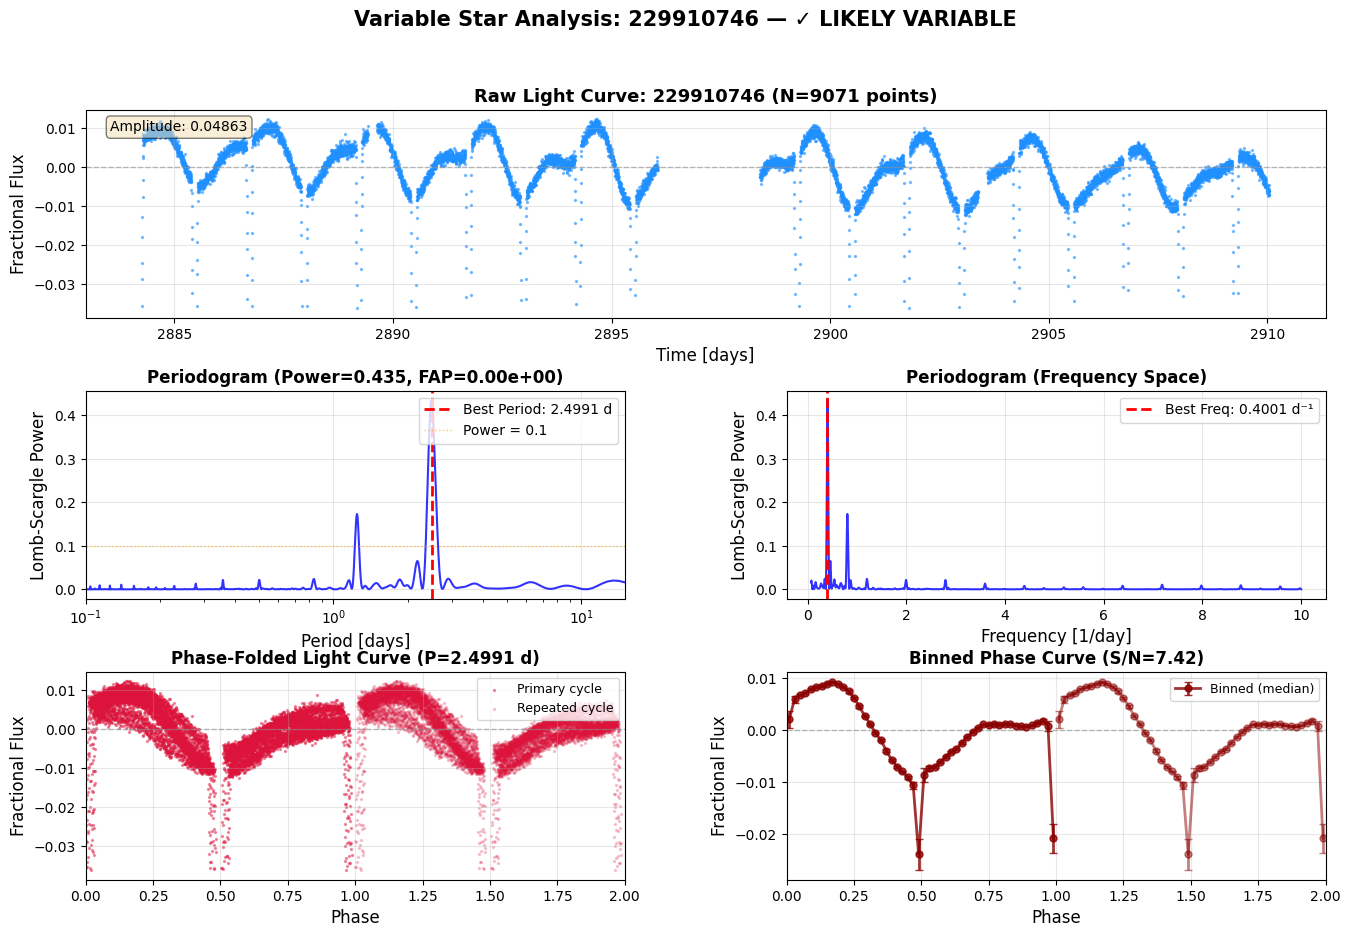


ANALYSIS SUMMARY: 229910746
  Period:              2.499117 days
  LS Power:            0.4354  (Strong)
  False Alarm Prob:    0.00e+00  (Significant)
  Amplitude:           0.048629
  Signal-to-Noise:     7.42
  N Points:            9071
  RA, Dec:             287.3495, 61.8378

INTERPRETATION GUIDE:
  • LS Power > 0.3:     Strong periodic signal
  • LS Power 0.1-0.3:   Marginal signal, may be variable
  • LS Power < 0.1:     Likely just noise/non-periodic
  • FAP < 0.01:         Statistically significant period
  • FAP > 0.01:         Period may be spurious


USAGE EXAMPLES:
# Get high-quality variables:
good_vars = filter_variable_stars(results, quality='high')

# Analyze any star manually:
analyze_star_variability(results[0])  # Change index as needed

# Filter by LS power:
for star in results:
    if star['ls_power'] > 0.3:
        analyze_star_variability(star)

✅ Analysis complete!


In [254]:
from datasets import load_dataset
import pandas as pd
import numpy as np
from astropy.timeseries import LombScargle
from tqdm import tqdm
import matplotlib.pyplot as plt

print("Loading TESS dataset...")
tess_data = load_dataset(
    "MultimodalUniverse/tess",
    split="train",
    streaming=True
)
print("Loaded")

# ============================================================
# CORE FUNCTIONS
# ============================================================

def compute_features(time, flux, flux_err, min_period=0.1, max_period=15.0):
    """Find the best period using Lomb-Scargle."""
    min_freq = 1 / max_period
    max_freq = 1 / min_period
    
    ls = LombScargle(time, flux, flux_err)
    frequency, power = ls.autopower(
        minimum_frequency=min_freq,
        maximum_frequency=max_freq,
        samples_per_peak=10
    )
    
    best_freq = frequency[np.argmax(power)]
    best_period = 1 / best_freq
    best_power = np.max(power)
    fap = ls.false_alarm_probability(best_power)
    
    return {
        'period': best_period,
        'ls_power': best_power,
        'fap': fap,
        'amplitude': np.ptp(flux),
        'signal_to_noise': np.ptp(flux) / np.std(flux) if np.std(flux) > 0 else 0,
        'n_points': len(time),
        'frequencies': frequency,
        'powers': power
    }

def clean_para(time, flux, flux_err):
    """Clean and normalize light curve data."""
    time, flux, flux_err = np.array(time), np.array(flux), np.array(flux_err)
    mask = ~(np.isnan(time) | np.isnan(flux)) & (flux > 0)
    time, flux, flux_err = time[mask], flux[mask], flux_err[mask]
    
    if len(time) == 0:
        return time, flux, flux_err
    
    med = np.median(flux)
    flux_norm = flux / med - 1.0
    flux_err_norm = flux_err / med
    return time, flux_norm, flux_err_norm

def rem_outliers(time, flux, flux_err=None, sigma=5):
    """Remove outliers using MAD."""
    if len(time) == 0:
        return time, flux, flux_err
    if flux_err is None:
        flux_err = np.ones_like(flux) * np.std(flux) * 0.01
    med = np.nanmedian(flux)
    mad = np.nanmedian(np.abs(flux - med))
    if mad == 0 or np.isnan(mad):
        mad = np.nanstd(flux)
    if mad == 0:
        return time, flux, flux_err
    mask = np.abs(flux - med) < sigma * 1.4826 * mad
    return time[mask], flux[mask], flux_err[mask]

def compute_phase(time, period, t0=None):
    """Compute phase for each time point."""
    if t0 is None:
        t0 = np.nanmin(time)
    phase = ((time - t0) / period) % 1.0
    return phase

# ============================================================
# NEW FUNCTION: Complete diagnostic plot as professor suggested
# ============================================================

def analyze_star_variability(star_data, figsize=(16, 10)):
    """
    Complete diagnostic analysis of a potential variable star.
    Shows: raw light curve, periodogram, phase-folded curve, and binned phase curve.
    
    Parameters:
    -----------
    star_data : dict
        Dictionary containing 'time', 'flux', 'flux_err', 'phase', 'period',
        'frequencies', 'powers', and other metadata
    figsize : tuple
        Figure size (width, height)
    """
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)
    
    # Extract data
    time = star_data['time']
    flux = star_data['flux']
    flux_err = star_data['flux_err']
    phase = star_data['phase']
    period = star_data['period']
    frequencies = star_data['frequencies']
    powers = star_data['powers']
    periods = 1 / frequencies
    
    # ========================================
    # Panel 1: Raw Light Curve (top, full width)
    # ========================================
    ax1 = fig.add_subplot(gs[0, :])
    ax1.scatter(time, flux, s=2, alpha=0.5, color='dodgerblue', rasterized=True)
    ax1.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax1.set_xlabel('Time [days]', fontsize=12)
    ax1.set_ylabel('Fractional Flux', fontsize=12)
    ax1.set_title(f'Raw Light Curve: {star_data["object_id"]} (N={len(time)} points)', 
                  fontsize=13, fontweight='bold')
    ax1.grid(alpha=0.3)
    
    # Add amplitude annotation
    amp = star_data['amplitude']
    ax1.text(0.02, 0.95, f'Amplitude: {amp:.5f}', 
             transform=ax1.transAxes, fontsize=10,
             verticalalignment='top', bbox=dict(boxstyle='round', 
             facecolor='wheat', alpha=0.5))
    
    # ========================================
    # Panel 2: Lomb-Scargle Periodogram
    # ========================================
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(periods, powers, 'b-', linewidth=1.5, alpha=0.8)
    ax2.axvline(period, color='red', linestyle='--', linewidth=2, 
                label=f'Best Period: {period:.4f} d')
    ax2.axhline(0.1, color='orange', linestyle=':', linewidth=1, alpha=0.6, 
                label='Power = 0.1')
    ax2.set_xlabel('Period [days]', fontsize=12)
    ax2.set_ylabel('Lomb-Scargle Power', fontsize=12)
    ax2.set_title(f'Periodogram (Power={star_data["ls_power"]:.3f}, FAP={star_data["fap"]:.2e})', 
                  fontsize=12, fontweight='bold')
    ax2.set_xscale('log')
    ax2.set_xlim(periods.min(), periods.max())
    ax2.legend(fontsize=10, loc='upper right')
    ax2.grid(alpha=0.3)
    
    # ========================================
    # Panel 3: Frequency Space (alternative view)
    # ========================================
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.plot(frequencies, powers, 'b-', linewidth=1.5, alpha=0.8)
    ax3.axvline(1/period, color='red', linestyle='--', linewidth=2,
                label=f'Best Freq: {1/period:.4f} d⁻¹')
    ax3.set_xlabel('Frequency [1/day]', fontsize=12)
    ax3.set_ylabel('Lomb-Scargle Power', fontsize=12)
    ax3.set_title('Periodogram (Frequency Space)', fontsize=12, fontweight='bold')
    ax3.legend(fontsize=10, loc='upper right')
    ax3.grid(alpha=0.3)
    
    # ========================================
    # Panel 4: Phase-Folded Light Curve
    # ========================================
    ax4 = fig.add_subplot(gs[2, 0])
    
    # Sort by phase
    sort_idx = np.argsort(phase)
    phase_sorted = phase[sort_idx]
    flux_sorted = flux[sort_idx]
    
    # Plot two cycles for continuity
    ax4.scatter(phase_sorted, flux_sorted, s=2, alpha=0.4, color='crimson', 
                label='Primary cycle', rasterized=True)
    ax4.scatter(phase_sorted + 1, flux_sorted, s=2, alpha=0.2, color='crimson',
                label='Repeated cycle', rasterized=True)
    ax4.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax4.set_xlabel('Phase', fontsize=12)
    ax4.set_ylabel('Fractional Flux', fontsize=12)
    ax4.set_title(f'Phase-Folded Light Curve (P={period:.4f} d)', 
                  fontsize=12, fontweight='bold')
    ax4.set_xlim(0, 2)
    ax4.legend(fontsize=9, loc='upper right')
    ax4.grid(alpha=0.3)
    
    # ========================================
    # Panel 5: Binned Phase Curve (cleaner view)
    # ========================================
    ax5 = fig.add_subplot(gs[2, 1])
    
    # Bin the phase curve
    n_bins = 50
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    binned_flux = []
    binned_flux_err = []
    
    for i in range(n_bins):
        mask = (phase >= bin_edges[i]) & (phase < bin_edges[i+1])
        if np.sum(mask) > 0:
            binned_flux.append(np.median(flux[mask]))
            binned_flux_err.append(np.std(flux[mask]) / np.sqrt(np.sum(mask)))
        else:
            binned_flux.append(np.nan)
            binned_flux_err.append(np.nan)
    
    binned_flux = np.array(binned_flux)
    binned_flux_err = np.array(binned_flux_err)
    
    # Plot binned data with error bars
    ax5.errorbar(bin_centers, binned_flux, yerr=binned_flux_err,
                fmt='o-', markersize=5, color='darkred', linewidth=2,
                capsize=3, alpha=0.8, label='Binned (median)')
    ax5.errorbar(bin_centers + 1, binned_flux, yerr=binned_flux_err,
                fmt='o-', markersize=5, color='darkred', linewidth=2,
                capsize=3, alpha=0.5)
    ax5.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax5.set_xlabel('Phase', fontsize=12)
    ax5.set_ylabel('Fractional Flux', fontsize=12)
    ax5.set_title(f'Binned Phase Curve (S/N={star_data["signal_to_noise"]:.2f})', 
                  fontsize=12, fontweight='bold')
    ax5.set_xlim(0, 2)
    ax5.legend(fontsize=9, loc='upper right')
    ax5.grid(alpha=0.3)
    
    # Overall title with quality assessment
    quality_str = "✓ LIKELY VARIABLE" if (star_data['ls_power'] > 0.3 and 
                                          star_data['fap'] < 0.01) else "? MARGINAL/NON-VARIABLE"
    fig.suptitle(f'Variable Star Analysis: {star_data["object_id"]} — {quality_str}',
                fontsize=15, fontweight='bold')
    
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*70)
    print(f"ANALYSIS SUMMARY: {star_data['object_id']}")
    print("="*70)
    print(f"  Period:              {period:.6f} days")
    print(f"  LS Power:            {star_data['ls_power']:.4f}  {'(Strong)' if star_data['ls_power'] > 0.3 else '(Weak)'}")
    print(f"  False Alarm Prob:    {star_data['fap']:.2e}  {'(Significant)' if star_data['fap'] < 0.01 else '(Not significant)'}")
    print(f"  Amplitude:           {star_data['amplitude']:.6f}")
    print(f"  Signal-to-Noise:     {star_data['signal_to_noise']:.2f}")
    print(f"  N Points:            {star_data['n_points']}")
    print(f"  RA, Dec:             {star_data['ra']:.4f}, {star_data['dec']:.4f}")
    print("="*70)
    
    # Interpretation guide
    print("\nINTERPRETATION GUIDE:")
    print("  • LS Power > 0.3:     Strong periodic signal")
    print("  • LS Power 0.1-0.3:   Marginal signal, may be variable")
    print("  • LS Power < 0.1:     Likely just noise/non-periodic")
    print("  • FAP < 0.01:         Statistically significant period")
    print("  • FAP > 0.01:         Period may be spurious")
    print("="*70 + "\n")

# ============================================================
# PROCESS DATA
# ============================================================

results = []
max_samples = 20  # ← INCREASED from 20 to 100 to find variables!

print("\nProcessing light curves to find variable stars...")
print("(Most stars are NOT variable - we need to check many to find good ones)")
for i, sample in enumerate(tqdm(tess_data, total=max_samples)):
    if i >= max_samples:
        break
    
    try:
        lc = sample['lightcurve']
        time = np.array(lc['time'])
        flux = np.array(lc['flux'])
        flux_err = np.array(lc.get('flux_err', np.ones_like(flux) * 0.01))
        
        # Clean data
        time, flux, flux_err = clean_para(time, flux, flux_err)
        if len(time) < 100:
            continue
        time, flux, flux_err = rem_outliers(time, flux, flux_err)
        if len(time) < 100:
            continue
        
        # Compute features
        features = compute_features(time, flux, flux_err, min_period=0.1, max_period=15.0)
        period = features['period']
        phase = compute_phase(time, period)
        
        # Store result
        result = {
            'object_id': sample['object_id'],
            'ra': sample['RA'],
            'dec': sample['DEC'],
            'time': time,
            'flux': flux,
            'flux_err': flux_err,
            'phase': phase,
            **features
        }
        results.append(result)
        
    except Exception as e:
        continue

# Convert to DataFrame and sort by quality
df = pd.DataFrame(results)
df_sorted = df.sort_values('ls_power', ascending=False)

print(f"\n{'='*70}")
print(f"PROCESSED {len(df)} OBJECTS")
print(f"{'='*70}")
print("\nTop 10 by Lomb-Scargle Power:")
print(df_sorted[['object_id', 'period', 'ls_power', 'fap', 'amplitude', 'signal_to_noise']].head(10).to_string(index=False))
print(f"{'='*70}\n")

# ============================================================
# QUALITY-BASED FILTERING (WITHOUT FAP)
# ============================================================

def filter_variable_stars(results_list, quality='high'):
    """
    Filter stars based on periodicity quality (no FAP needed).
    
    Parameters:
    -----------
    results_list : list
        List of star result dictionaries
    quality : str
        'high' - Strong periodic signals (LS power > 0.3)
        'medium' - Moderate signals (LS power > 0.2)
        'any' - Any detectable periodicity (LS power > 0.1)
    
    Returns:
    --------
    filtered_list : list
        Stars meeting the quality criteria
    """
    filtered = []
    
    for star in results_list:
        if quality == 'high':
            # Strict criteria: Strong periodic signal
            if (star['ls_power'] > 0.3 and               # Strong periodogram peak
                star['signal_to_noise'] > 3 and          # Clear signal above noise
                star['amplitude'] > 0.001):              # Detectable amplitude
                filtered.append(star)
                
        elif quality == 'medium':
            # Moderate criteria: Decent periodic signal
            if (star['ls_power'] > 0.2 and               # Moderate periodogram peak
                star['signal_to_noise'] > 2 and          # Some signal above noise
                star['amplitude'] > 0.0005):             # Small but detectable
                filtered.append(star)
                
        elif quality == 'any':
            # Relaxed criteria: Any hint of periodicity
            if star['ls_power'] > 0.1:                   # Some periodogram peak
                filtered.append(star)
    
    return filtered

# Apply filters
high_quality_vars = filter_variable_stars(results, quality='high')
medium_quality_vars = filter_variable_stars(results, quality='medium')
any_periodicity = filter_variable_stars(results, quality='any')

print("\n" + "="*70)
print("QUALITY-BASED FILTERING RESULTS")
print("="*70)
print(f"Total objects processed:        {len(results)}")
print(f"High-quality variables:         {len(high_quality_vars)} (LS power > 0.3)")
print(f"Medium-quality variables:       {len(medium_quality_vars)} (LS power > 0.2)")
print(f"Any periodicity detected:       {len(any_periodicity)} (LS power > 0.1)")
print(f"Non-variable/noise:             {len(results) - len(any_periodicity)}")
print("="*70)

# Show the top candidates regardless of threshold
print("\n" + "="*70)
print("TOP 10 CANDIDATES BY LS POWER (even if below threshold):")
print("="*70)
for i in range(min(10, len(df_sorted))):
    idx = df_sorted.index[i]
    star = results[idx]
    quality_marker = "✓✓✓" if star['ls_power'] > 0.3 else ("✓✓" if star['ls_power'] > 0.2 else ("✓" if star['ls_power'] > 0.1 else "?"))
    print(f"{quality_marker} results[{idx:2d}]: {star['object_id']:<12} | "
          f"LS={star['ls_power']:.4f} | P={star['period']:.4f}d | Amp={star['amplitude']:.5f}")
print("="*70)

# ============================================================
# ANALYZE FILTERED STARS
# ============================================================

# Analyze high-quality variables
if len(high_quality_vars) > 0:
    print("\n" + "#"*70)
    print(f"# FOUND {len(high_quality_vars)} HIGH-QUALITY VARIABLE STARS! 🌟")
    print("#"*70)
    
    # Analyze first few high-quality variables
    for i, star in enumerate(high_quality_vars[:3]):  # Show up to 3
        result_idx = results.index(star)
        print(f"\n{'='*70}")
        print(f"HIGH-QUALITY VARIABLE #{i+1} (results[{result_idx}])")
        print('='*70)
        analyze_star_variability(star)
        
elif len(medium_quality_vars) > 0:
    print("\n" + "#"*70)
    print(f"# NO HIGH-QUALITY VARIABLES, BUT FOUND {len(medium_quality_vars)} MEDIUM-QUALITY")
    print("#"*70)
    
    # Analyze first medium-quality variable
    for i, star in enumerate(medium_quality_vars[:2]):  # Show up to 2
        result_idx = results.index(star)
        print(f"\n{'='*70}")
        print(f"MEDIUM-QUALITY VARIABLE #{i+1} (results[{result_idx}])")
        print('='*70)
        analyze_star_variability(star)
        
elif len(any_periodicity) > 0:
    print("\n" + "#"*70)
    print(f"# FOUND {len(any_periodicity)} STARS WITH MARGINAL PERIODICITY")
    print("#"*70)
    
    # Analyze the best marginal candidate
    result_idx = results.index(any_periodicity[0])
    print(f"\n{'='*70}")
    print(f"BEST MARGINAL CANDIDATE (results[{result_idx}])")
    print('='*70)
    analyze_star_variability(any_periodicity[0])
    
else:
    print("\n" + "!"*70)
    print("! NO PERIODIC VARIABLES FOUND")
    print("!"*70)
    print("\nThis is NORMAL - most stars are not strongly variable!")
    print(f"Out of {len(results)} stars checked, none show clear periodicity.")
    print("\nRECOMMENDATIONS:")
    print("1. Increase max_samples to 200-500 to find more candidates")
    print("2. The TESS dataset has many non-variable stars")
    print("3. Showing the BEST candidate anyway (even if not truly variable):\n")
    
    if len(results) > 0:
        best_idx = df_sorted.index[0]
        best_star = results[best_idx]
        print(f"Best available: results[{best_idx}] with LS power = {best_star['ls_power']:.4f}")
        analyze_star_variability(best_star)

print("\n" + "="*70)
print("USAGE EXAMPLES:")
print("="*70)
print("# Get high-quality variables:")
print("good_vars = filter_variable_stars(results, quality='high')")
print("\n# Analyze any star manually:")
print("analyze_star_variability(results[0])  # Change index as needed")
print("\n# Filter by LS power:")
print("for star in results:")
print("    if star['ls_power'] > 0.3:")
print("        analyze_star_variability(star)")
print("="*70)

print("\n✅ Analysis complete!")